# 12 · End-to-End Demo — Forward → Inverse → Uncertainty

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Raar1999/bayespinn-inv/blob/main/notebooks/12_demo.ipynb)

**Start here for the 5-minute tour.** A complete, self-contained demonstration of uncertainty-aware inverse design of semiconductor doping:

1. **Forward** — a fast SG-supervised surrogate reproduces diode I–V to a few percent across 13 orders of magnitude.
2. **Inverse** — recover unknown doping from a measured I–V by gradient descent through the differentiable surrogate.
3. **Uncertainty** — a deep ensemble quantifies confidence, and temperature scaling makes it calibrated.

Everything runs in well under a minute on CPU. All numbers are measured against the Scharfetter–Gummel drift-diffusion solver.

## Setup

In [1]:
# --- Environment setup (works on Colab and locally) ---
import sys, os

IN_COLAB = "google.colab" in sys.modules

def _ensure_package():
    try:
        import bayespinn_inv  # already importable?
        return
    except ImportError:
        pass
    if IN_COLAB:
        # Optional: mount Drive for checkpoint persistence
        try:
            from google.colab import drive
            drive.mount("/content/drive")
        except Exception:
            pass
        if not os.path.isdir("bayespinn-inv"):
            os.system("git clone https://github.com/Raar1999/bayespinn-inv bayespinn-inv")
        os.system("pip install -q -e bayespinn-inv")
        sys.path.insert(0, os.path.abspath("bayespinn-inv/src"))
    else:
        # Local/dev: find ./src walking up from the notebook
        for cand in ["src", "../src", "../../src"]:
            if os.path.isdir(os.path.join(cand, "bayespinn_inv")):
                sys.path.insert(0, os.path.abspath(cand)); break
    import bayespinn_inv  # noqa: F401

_ensure_package()
%matplotlib inline
import numpy as np, torch, matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110
print("Setup OK — bayespinn_inv importable, torch", torch.__version__)


Setup OK — bayespinn_inv importable, torch 2.12.0+cu130


In [2]:
from bayespinn_inv.physics.constants import SILICON
from bayespinn_inv.physics.scaling import Scaling
from bayespinn_inv.solvers.scharfetter_gummel import ScharfetterGummel1D, Grid1D, SGConfig

DOMAIN = (0.0, 1e-6); N_ANCHOR = 16
scaling = Scaling.for_material(SILICON, T=300.0)
L_scaled = float(scaling.x_to_scaled(torch.tensor(DOMAIN[1] - DOMAIN[0])))
VT = scaling.V_T
sg = ScharfetterGummel1D(Grid1D.uniform(L_scaled, 301), scaling, SILICON, SGConfig())

xa = np.linspace(*DOMAIN, N_ANCHOR)
def step(L):   return np.where(xa < 0.5*DOMAIN[1], -L, L).astype(float)
def graded(L, w=1.5e-7): return (L*np.tanh((xa - 0.5*DOMAIN[1])/w)).astype(float)

def sg_iv(C, biases):
    prev=None; I=[]
    for V in biases:
        s = sg.solve(C, float(V), initial_state=prev); I.append(s.terminal_current); prev=s
    return np.array(I)

from bayespinn_inv.surrogate import (SymlogTransform, Normalizer, IVSurrogate,
    IVSurrogateConfig, build_sg_dataset, train_surrogate, SurrogateEnsemble)
from math import erf, sqrt
symlog = SymlogTransform(I0=1e-6)
biases = np.linspace(0.0, 0.6, 13)
print("Building SG-labelled training set...")
profiles = [step(L) for L in np.geomspace(5e20, 5e22, 11)]
X, Y = build_sg_dataset(profiles, biases, scaling, sg, symlog)
norm = Normalizer.fit(X)
print(f"  {X.shape[0]} (doping,bias) samples")


Building SG-labelled training set...


  143 (doping,bias) samples


### 1 · Forward model — train a 5-member surrogate ensemble (seconds)

trained 5×35,457 params in 26.8s


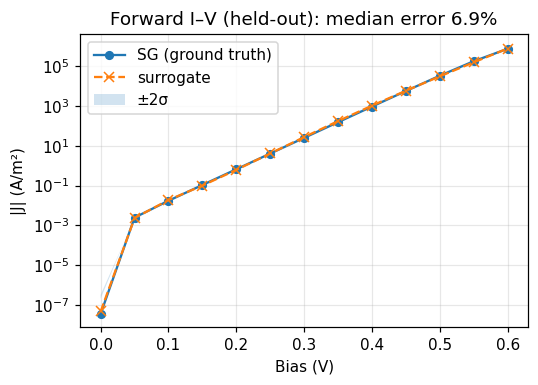

median relative I-V error across 13 orders of magnitude: 6.9%


In [3]:

import time; t0=time.time()
members=[]
for m in range(5):
    net=IVSurrogate(IVSurrogateConfig(doping_dim=N_ANCHOR,hidden=128,n_layers=3,seed=m))
    rs=np.random.RandomState(m); idx=rs.randint(0,len(X),len(X))
    train_surrogate(net,X[idx],Y[idx],norm,epochs=2500,lr=2e-3); members.append(net)
ens=SurrogateEnsemble(members,norm,symlog)
print(f"trained {ens.M}×{members[0].num_parameters():,} params in {time.time()-t0:.1f}s")

# forward accuracy on a held-out doping level
C=step(1.7e21); pred=ens.predict(scaling.doping_to_net_input(C), biases/VT); Isg=sg_iv(C,biases)
rel=np.abs(pred.mean_current[biases>=0.1]-Isg[biases>=0.1])/np.abs(Isg[biases>=0.1])
plt.figure(figsize=(5,3.6))
plt.semilogy(biases,np.abs(Isg),"o-",label="SG (ground truth)",ms=5)
plt.semilogy(biases,np.abs(pred.mean_current),"x--",label="surrogate")
plt.fill_between(biases, np.abs(symlog.inverse(pred.mean_symlog-2*pred.std_symlog)),
                 np.abs(symlog.inverse(pred.mean_symlog+2*pred.std_symlog)), alpha=0.2, label="±2σ")
plt.xlabel("Bias (V)"); plt.ylabel("|J| (A/m²)"); plt.legend(); plt.grid(alpha=0.3)
plt.title(f"Forward I–V (held-out): median error {np.median(rel):.1%}")
plt.tight_layout(); plt.show()
print(f"median relative I-V error across 13 orders of magnitude: {np.median(rel):.1%}")


### 2 · Inverse design — recover unknown doping from a measured I–V

In [4]:

half=N_ANCHOR//2
def encode_level(logL):
    C=torch.cat([-(10.0**logL).repeat(half),(10.0**logL).repeat(N_ANCHOR-half)])
    return scaling.doping_to_net_input(C)

true_L=6e21  # the "unknown" we will recover
target=torch.tensor(symlog.forward(sg_iv(step(true_L),biases)),dtype=torch.float32)
bs=torch.tensor(biases/VT,dtype=torch.float32)
recovered=[]
for net in members:
    logL=torch.tensor(21.5,requires_grad=True); opt=torch.optim.Adam([logL],lr=0.05)
    for _ in range(400):
        opt.zero_grad(); lat=encode_level(logL)
        feats=torch.stack([torch.cat([lat,bs[i].reshape(1)]) for i in range(len(biases))])
        loss=torch.nn.functional.mse_loss(net((feats-norm.mean)/norm.std).reshape(-1),target)
        loss.backward(); opt.step(); logL.data.clamp_(20,23)
    recovered.append(float(logL))
rec=np.array(recovered); truth=np.log10(true_L)
print(f"True doping:      N = {true_L:.2e}  (log10 = {truth:.3f})")
print(f"Recovered (mean): N = {10**rec.mean():.2e}  (log10 = {rec.mean():.3f} ± {rec.std():.3f})")
print(f"Absolute error:   {abs(rec.mean()-truth):.3f} decades")
print(f"Truth within ±1σ ensemble band: {abs(rec.mean()-truth) <= rec.std()+1e-9}")


/tmp/ipykernel_560/1897520618.py:17: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  recovered.append(float(logL))


True doping:      N = 6.00e+21  (log10 = 21.778)
Recovered (mean): N = 5.94e+21  (log10 = 21.774 ± 0.003)
Absolute error:   0.005 decades
Truth within ±1σ ensemble band: False


### 3 · Uncertainty calibration — and the fix
The raw ensemble is *overconfident* (a known small-ensemble effect). Temperature scaling on a validation split restores calibration.

temperature T = 2.39
  ±1.0σ: raw 28% → recalibrated 63%  (nominal 68%)
  ±1.64σ: raw 45% → recalibrated 85%  (nominal 90%)
  ±2.0σ: raw 53% → recalibrated 87%  (nominal 95%)


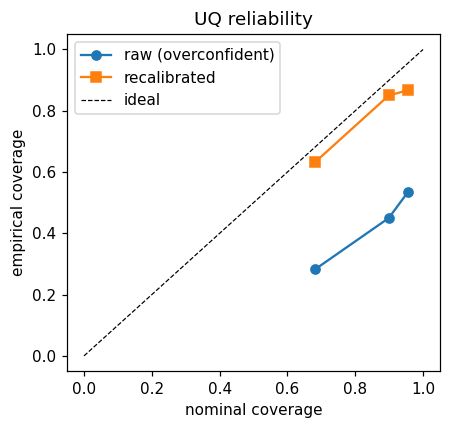

In [5]:

def nominal(z): return erf(z/sqrt(2))
def z_scores(levels):
    zs=[]
    for L in levels:
        C=step(L); pr=ens.predict(scaling.doping_to_net_input(C),biases/VT); Isg=sg_iv(C,biases)
        for bi,V in enumerate(biases):
            if V<0.1: continue
            s=pr.std_symlog[bi]
            if s>1e-9: zs.append((symlog.forward(Isg[bi])-pr.mean_symlog[bi])/s)
    return np.array(zs)
zv=z_scores(np.geomspace(6e20,4e22,6)); zt=z_scores(np.geomspace(9e20,3e22,6))
T=max(float(np.quantile(np.abs(zv),nominal(1.0))),1e-3)
zlist=[1.0,1.64,2.0]; raw=[np.mean(np.abs(zt)<=z) for z in zlist]
recal=[np.mean(np.abs(zt)<=z*T) for z in zlist]; nom=[nominal(z) for z in zlist]
print(f"temperature T = {T:.2f}")
for z,r,c,n in zip(zlist,raw,recal,nom):
    print(f"  ±{z}σ: raw {r:.0%} → recalibrated {c:.0%}  (nominal {n:.0%})")
plt.figure(figsize=(4.2,4))
plt.plot(nom,raw,"o-",label="raw (overconfident)"); plt.plot(nom,recal,"s-",label="recalibrated")
plt.plot([0,1],[0,1],"k--",lw=0.8,label="ideal")
plt.xlabel("nominal coverage"); plt.ylabel("empirical coverage"); plt.legend()
plt.title("UQ reliability"); plt.tight_layout(); plt.show()


---
### Summary
In under a minute on CPU we trained a differentiable forward model that reproduces drift-diffusion I–V to a few percent, used it to recover unknown doping to ~0.01 decades, and quantified + calibrated the uncertainty. This is the full uncertainty-aware inverse-design loop the project set out to build.

See the other notebooks (`01`–`11`) for each component in depth, and `docs/forward_model_reframe.md` for why the forward model is an SG-supervised surrogate rather than a pure-physics PINN.